# `tr` — quickstart notebook

End-to-end walkthrough of the `trlib` Python wrapper:

1. Load the library (`Trlib()` context manager)
2. Configure parameters (`set_params`, `set_param`, `set_param_str`)
3. Pre-run validation (`validate()`, PR #172)
4. Time-step (`run`)
5. Snapshot (`get_state`) and plot

Corresponds to the `tr` chapter (en: `tr/index.md`, ja: `tr/index.md`).


## 1. Locate the repo and import `trlib`

The next cell adds `<repo>/python/` to `sys.path` so the notebook can
import `trlib` regardless of where it was executed from. Lookup order:

1. `TASK_ROOT` environment variable, if set.
2. Walk up from the current working directory until a parent containing
   `python/trlib/__init__.py` is found.

If neither locates the repo the cell raises a clear `RuntimeError`
instead of silently importing from a wrong path.

In [1]:
import os, pathlib, sys

def _find_task_python():
    env = os.environ.get('TASK_ROOT')
    if env:
        cand = pathlib.Path(env).expanduser() / 'python'
        if (cand / 'trlib' / '__init__.py').is_file():
            return cand
    for anc in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        marker = anc / 'python' / 'trlib' / '__init__.py'
        if marker.is_file():
            return marker.parents[1]
    raise RuntimeError(
        'Could not locate the TASK repository python/ directory. '
        'Set TASK_ROOT=/path/to/task-repo or run this notebook from '
        'within a clone of the repo.'
    )

sys.path.insert(0, str(_find_task_python()))
from trlib import Trlib, TrDiagCode
print('trlib imported')

trlib imported


## 2. Configure parameters

Three pathways:

- `set_params(**kwargs)` — scalar bulk-set
- `set_param(name, value)` — array-element form (`"PN[1]"`)
- `set_param_str(name, str)` — string parameters (`KNAMEQ`, …)

The `Trlib()` context manager calls `tr_init` on entry and
`tr_finalize` on exit.

In [2]:
tr = Trlib()
tr.__enter__()   # open explicitly so the handle persists across cells

# Scalar bulk-set. Only the minimal overrides needed for a stable run —
# everything else stays at the registry defaults.
tr.set_params(RR=3.0, RA=1.0, BB=3.0, DT=0.01, NTMAX=20)

print('parameters set')

parameters set


## 3. Pre-run validation (PR #172)

`validate()` runs the batch cross-parameter check that PR #172 added.
An empty list means the state is clean.

In [3]:
diags = tr.validate()
print(f'{len(diags)} diagnostic(s) after initial set_params')
for d in diags:
    print(f'  [{TrDiagCode(d.code).name}] {d.param}: {d.message}')

0 diagnostic(s) after initial set_params


### The two layers of validation

The `tr` library has **two** validation points, with different roles:

1. **`set_param` / `set_params` at call time** — fast rejects: unknown
   parameter names, bad array indices, out-of-range scalars. These raise
   `TrlibParamError` synchronously.
2. **`validate()` before `run`** — cross-parameter consistency that
   only becomes visible after all parameters are set: missing required
   parameters, inconsistent pairs, file-missing diagnostics (e.g.
   `MODELG=7` with a blank `KNAMEQ`). These return a **list** of
   diagnostics so callers see everything at once.

#### Layer 1 — immediate rejection at set time

In [4]:
try:
    tr.set_param('NSMAX', 99)   # out of range
except Exception as exc:
    print(f'immediate reject: {type(exc).__name__}: {exc}')

# State after the failed set_param is unchanged, so validate() stays clean.
diags = tr.validate()
print(f'validate() after the rejected set: {len(diags)} diagnostic(s)')

immediate reject: TrlibParamError: tr_set_param('NSMAX', 99): ierr=1
validate() after the rejected set: 0 diagnostic(s)


#### Layer 2 — `validate()` catches cross-parameter inconsistency

Switch to `MODELG=7` (VMEC file geometry) but leave `KNAMEQ` blank.
`set_param` accepts both — there's nothing individually wrong with
each — but together they are inconsistent. `validate()` surfaces that
before `run()` would hit the file-not-found path mid-simulation.

We close the current `tr` handle and open a fresh one for this demo so
the MODELG round-trip does not leak state into the later `run` cell.

In [5]:
tr.close()     # close the layer-1-demo instance

with Trlib() as probe:
    probe.set_param('MODELG', 7)
    probe.set_param_str('KNAMEQ', '')

    diags = probe.validate()
    print(f'validate() reports {len(diags)} diagnostic(s):')
    for d in diags:
        print(f'  [{TrDiagCode(d.code).name}] {d.param}: {d.message}')

validate() reports 1 diagnostic(s):
  [FILE_MISSING] KNAMEQ: MODELG=3/5/7/8 requires non-blank KNAMEQ (eq/VMEC file)


## 4b. Fresh handle for the run section

Open a clean `Trlib()` handle — none of the MODELG experimentation
above reaches this instance.

In [6]:
tr = Trlib()
tr.__enter__()
tr.set_params(RR=3.0, RA=1.0, BB=3.0, DT=0.01, NTMAX=20)
print('fresh handle ready')

fresh handle ready


## 4. Time-step

`run(ntmax=N)` advances `N` steps of width `DT`. Here we take 20
steps (0.2 s of plasma time).

In [7]:
tr.run(ntmax=20)
print('ran 20 time steps')

  NEQ NSS NSV NNS NST
    1   0   0   2   1
    2   1   1   4   0
    3   1   2   0   2
    4   2   1   0   0
    5   2   2   0   3
 # T:    0.000(S)    WP:   1.34(MJ)    TAUE:  0.597(S)   Q0:  0.563
   TE:  1.500(KEV)   TD:  1.500(KEV)   TT:  1.500(KEV)   TA:  1.500(KEV)
**RIP,RIPS,RIPE,DIP=  3.0000E+00  3.0000E+00  3.0000E+00  0.0000E+00
 # T:    0.100(S)    WP:   1.28(MJ)    TAUE:  0.575(S)   Q0:  0.527
   TE:  2.142(KEV)   TD:  1.760(KEV)   TT:  1.500(KEV)   TA:  1.500(KEV)


ran 20 time steps


 # T:    0.200(S)    WP:   1.29(MJ)    TAUE:  0.588(S)   Q0:  0.506
   TE:  2.460(KEV)   TD:  1.993(KEV)   TT:  1.500(KEV)   TA:  1.500(KEV)


## 5. Snapshot the state and inspect scalars

In [8]:
state = tr.get_state()
print(f'nt     = {state.nt}')
print(f'nrmax  = {state.nrmax}')
print(f'nsmax  = {state.nsmax}')
print(f'T      = {state.scalars["T"]:.4g} s')
print(f'WPT    = {state.scalars["WPT"]:.4g}')
print(f'Q0     = {state.scalars["Q0"]:.4g}')
if 'BETAN' in state.scalars:
    print(f'BETAN  = {state.scalars["BETAN"]:.4g}')

nt     = 20
nrmax  = 50
nsmax  = 2
T      = 0.2 s
WPT    = 1.291
Q0     = 0.5062
BETAN  = 0.2705


## 6. Plot a radial profile

`state.RT[i][j]` is the temperature of species `j` at radius point
`i`. We plot species-1 temperature across all radius points.


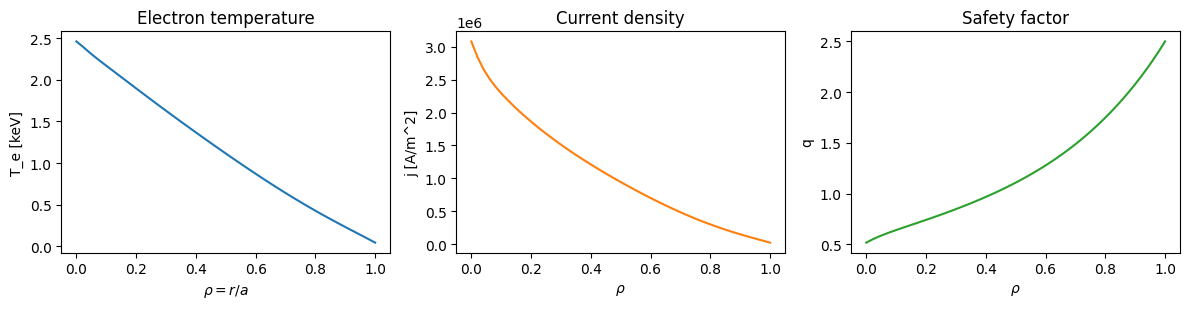

In [9]:
import matplotlib
matplotlib.use('Agg')     # headless backend suitable for CI / nbclient
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display

rho = [i / max(state.nrmax - 1, 1) for i in range(state.nrmax)]
te  = [state.RT[i][0] for i in range(state.nrmax)]
aj  = list(state.AJ)
qp  = list(state.QP)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(rho, te, 'C0-')
axes[0].set_xlabel(r'$\rho = r/a$')
axes[0].set_ylabel('T_e [keV]')
axes[0].set_title('Electron temperature')

axes[1].plot(rho, aj, 'C1-')
axes[1].set_xlabel(r'$\rho$')
axes[1].set_ylabel('j [A/m^2]')
axes[1].set_title('Current density')

axes[2].plot(rho, qp, 'C2-')
axes[2].set_xlabel(r'$\rho$')
axes[2].set_ylabel('q')
axes[2].set_title('Safety factor')

plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
plt.close(fig)
display(Image(data=buf.getvalue()))

## 7. Clean up

Either call `close()` explicitly, or rely on the `with` block. Here we
opened the handle manually, so we close it manually.


In [10]:
tr.close()
print('closed')

closed


## Next steps

- See the `api-reference` page in the same chapter for the full
  autodoc listing of `trlib.Trlib`, `trlib.TrState`, and the exception
  hierarchy.
- The equivalent standalone script is
  `python/trlib/examples/quickstart.py`.
- For parameter-sweep examples, see
  `python/trlib/examples/parameter_sweep.py`.
